<a href="https://colab.research.google.com/github/MinhPhuc635/CSE457-Audio-Speech-Processing/blob/main/Lab02_2351260681_NguyenMinhPhuc/Lab02_2351260681.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***TASK A - Thu dữ liệu và kiểm tra chất lượng***

# **Import**

In [ ]:
import os
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from pathlib import Path

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# **Khai báo đường dẫn**

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Audio/Lab02/dataset")

print("Dataset:", DATASET_DIR)

Dataset: /content/drive/MyDrive/Audio/Lab02/dataset


# **Liệt kê số lượng file**

In [ ]:
labels = sorted([
    folder.name
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print("Các lớp:", labels)

for label in labels:
    files = sorted((DATASET_DIR / label).glob("*.wav"))
    print(f"{label}: {len(files)} files")

Các lớp: ['ba', 'bon', 'hai', 'khong', 'mot']
ba: 5 files
bon: 5 files
hai: 5 files
khong: 5 files
mot: 5 files


# **Kiểm tra dataset**

In [ ]:
for label in labels:
    files = sorted((DATASET_DIR / label).glob("*.wav"))

    for file in files:
        y, sr = librosa.load(file, sr=None, mono=False)

        channels = 1 if y.ndim == 1 else y.shape[0]

        print(
            f"{file.name:20s} | "
            f"sr={sr:5d} | "
            f"channels={channels}"
        )

ba_01.wav            | sr=48000 | channels=2
ba_02.wav            | sr=48000 | channels=2
ba_03.wav            | sr=48000 | channels=2
ba_04.wav            | sr=48000 | channels=2
ba_05.wav            | sr=48000 | channels=2
bon_01.wav           | sr=48000 | channels=2
bon_02.wav           | sr=48000 | channels=2
bon_03.wav           | sr=48000 | channels=2
bon_04.wav           | sr=48000 | channels=2
bon_05.wav           | sr=48000 | channels=2
hai_01.wav           | sr=48000 | channels=2
hai_02.wav           | sr=48000 | channels=2
hai_03.wav           | sr=48000 | channels=2
hai_04.wav           | sr=48000 | channels=2
hai_05.wav           | sr=48000 | channels=2
khong_01.wav         | sr=48000 | channels=1
khong_02.wav         | sr=48000 | channels=1
khong_03.wav         | sr=48000 | channels=1
khong_04.wav         | sr=48000 | channels=1
khong_05.wav         | sr=48000 | channels=1
mot_01.wav           | sr=48000 | channels=1
mot_02.wav           | sr=48000 | channels=1
mot_03.wav

# **Chuẩn hóa dataset**

In [ ]:
OUTPUT_DIR = Path("/content/drive/MyDrive/Audio/Lab02/dataset_16k")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for label in labels:
    input_dir = DATASET_DIR / label
    output_dir = OUTPUT_DIR / label
    output_dir.mkdir(parents=True, exist_ok=True)

    for file in sorted(input_dir.glob("*.wav")):
        y, sr = librosa.load(file, sr=16000, mono=True)

        max_value = np.max(np.abs(y))

        if max_value > 0:
            y = y / max_value

        output_file = output_dir / file.name

        sf.write(output_file, y, 16000)

print("Đã chuẩn hóa dataset.")

Đã chuẩn hóa dataset.


# **Vẽ waveform**

In [ ]:
sample_files = [
    DATASET_DIR / "khong" / "khong_01.wav",
    DATASET_DIR / "mot" / "mot_01.wav",
    DATASET_DIR / "hai" / "hai_01.wav"
]

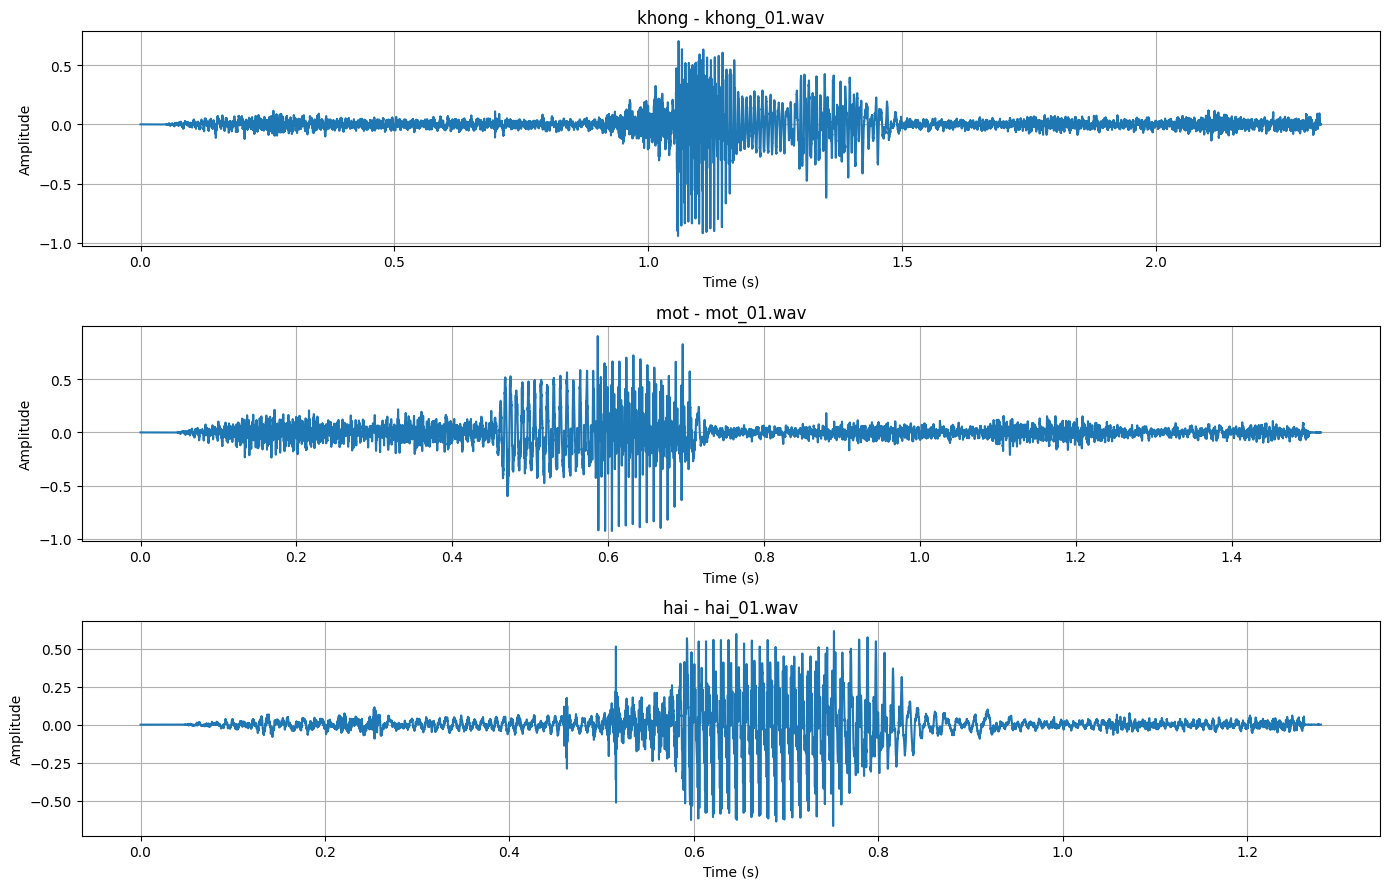

In [ ]:
plt.figure(figsize=(14, 9))

for i, file in enumerate(sample_files, 1):
    y, sr = librosa.load(file, sr=16000, mono=True)
    time = np.arange(len(y)) / sr

    plt.subplot(3, 1, i)
    plt.plot(time, y)
    plt.title(file.parent.name + " - " + file.name)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()

# **Kiểm tra clipping tự động**

In [ ]:
def check_clipping(file, threshold=0.999):
    y, sr = librosa.load(file, sr=None, mono=True)

    clipped = np.sum(np.abs(y) >= threshold)
    percentage = clipped / len(y) * 100

    return clipped, percentage


for label in labels:
    for file in sorted((DATASET_DIR / label).glob("*.wav")):
        clipped, percentage = check_clipping(file)

        print(
            f"{file.name:20s} | "
            f"clipped samples: {clipped:5d} | "
            f"{percentage:.4f}%"
        )

ba_01.wav            | clipped samples:     0 | 0.0000%
ba_02.wav            | clipped samples:     0 | 0.0000%
ba_03.wav            | clipped samples:     0 | 0.0000%
ba_04.wav            | clipped samples:     0 | 0.0000%
ba_05.wav            | clipped samples:     0 | 0.0000%
bon_01.wav           | clipped samples:     0 | 0.0000%
bon_02.wav           | clipped samples:     0 | 0.0000%
bon_03.wav           | clipped samples:     0 | 0.0000%
bon_04.wav           | clipped samples:     0 | 0.0000%
bon_05.wav           | clipped samples:     0 | 0.0000%
hai_01.wav           | clipped samples:     0 | 0.0000%
hai_02.wav           | clipped samples:     0 | 0.0000%
hai_03.wav           | clipped samples:     0 | 0.0000%
hai_04.wav           | clipped samples:     0 | 0.0000%
hai_05.wav           | clipped samples:     0 | 0.0000%
khong_01.wav         | clipped samples:     0 | 0.0000%
khong_02.wav         | clipped samples:     0 | 0.0000%
khong_03.wav         | clipped samples:     0 | 

# **Chia Train/Test**

In [ ]:
train_files = []
test_files = []

for label in labels:
    files = sorted((DATASET_DIR / label).glob("*.wav"))

    train_files.extend(files[:3])
    test_files.extend(files[3:])

print("Train:", len(train_files))
print("Test :", len(test_files))

Train: 15
Test : 10


# **Kiểm tra tránh Data Leakage**

In [ ]:
train_set = set(train_files)
test_set = set(test_files)

overlap = train_set.intersection(test_set)

print("Số file bị trùng:", len(overlap))

if len(overlap) == 0:
    print("OK - Không có data leakage.")
else:
    print("WARNING - Có file xuất hiện ở cả train và test!")

Số file bị trùng: 0
OK - Không có data leakage.


# ***TASK B — Short-Time Energy/RMS và ZCR***

# **Khai báo thông số**

In [23]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

SR = 16000

FRAME_MS = 25
HOP_MS = 10

FRAME_LENGTH = int(SR * FRAME_MS / 1000)
HOP_LENGTH = int(SR * HOP_MS / 1000)

print("Frame length:", FRAME_LENGTH)
print("Hop length:", HOP_LENGTH)

Frame length: 400
Hop length: 160


# **Hàm tính Energy**

In [ ]:
def short_time_energy(y, frame_length=400, hop_length=160):
    frames = librosa.util.frame(
        y,
        frame_length=frame_length,
        hop_length=hop_length
    )

    energy = np.sum(frames ** 2, axis=0)

    return energy

# **Hàm tính RMS**

In [19]:
def short_time_rms(y, frame_length=400, hop_length=160):
    frames = librosa.util.frame(
        y,
        frame_length=frame_length,
        hop_length=hop_length
    )

    rms = np.sqrt(np.mean(frames ** 2, axis=0))

    return rms

# **Hàm tính ZCR**

In [20]:
def short_time_zcr(y, frame_length=400, hop_length=160):
    frames = librosa.util.frame(
        y,
        frame_length=frame_length,
        hop_length=hop_length
    )

    signs = np.sign(frames)

    zcr = np.sum(
        signs[:-1] * signs[1:] < 0,
        axis=0
    ) / (frame_length - 1)

    return zcr

# **Tạo trục thời gian**

In [21]:
def frame_times(num_frames, frame_length=400, hop_length=160, sr=16000):
    return (
        np.arange(num_frames) * hop_length
        + frame_length / 2
    ) / sr

# **Kiểm tra một file**

In [22]:
file = DATASET_DIR / "khong" / "khong_01.wav"

y, sr = librosa.load(
    file,
    sr=16000,
    mono=True
)

print("Sample rate:", sr)
print("Number of samples:", len(y))
print("Duration:", len(y) / sr, "seconds")

Sample rate: 16000
Number of samples: 37206
Duration: 2.325375 seconds


# **Tính Energy, RMS và ZCR**

In [24]:
energy = short_time_energy(
    y,
    FRAME_LENGTH,
    HOP_LENGTH
)

rms = short_time_rms(
    y,
    FRAME_LENGTH,
    HOP_LENGTH
)

zcr = short_time_zcr(
    y,
    FRAME_LENGTH,
    HOP_LENGTH
)

times = frame_times(
    len(energy),
    FRAME_LENGTH,
    HOP_LENGTH,
    SR
)

print("Number of frames:", len(energy))
print("Energy shape:", energy.shape)
print("RMS shape:", rms.shape)
print("ZCR shape:", zcr.shape)

Number of frames: 231
Energy shape: (231,)
RMS shape: (231,)
ZCR shape: (231,)


# **Vẽ Waveform + Energy + ZCR**

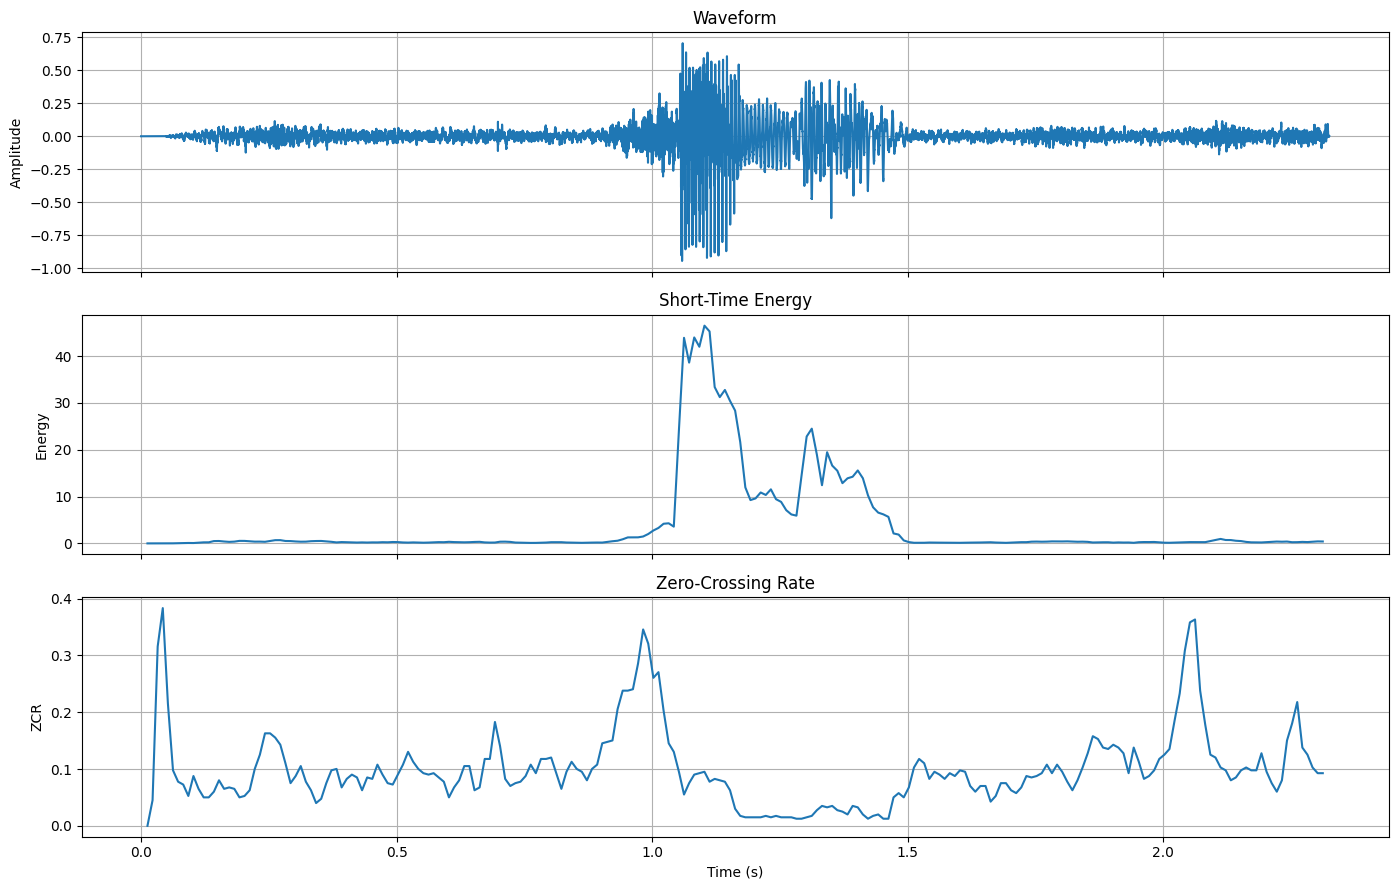

In [25]:
time_wave = np.arange(len(y)) / SR

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(time_wave, y)
axes[0].set_title("Waveform")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(times, energy)
axes[1].set_title("Short-Time Energy")
axes[1].set_ylabel("Energy")
axes[1].grid(True)

axes[2].plot(times, zcr)
axes[2].set_title("Zero-Crossing Rate")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("ZCR")
axes[2].grid(True)

plt.tight_layout()
plt.show()

# **Vẽ RMS thay cho Energy**

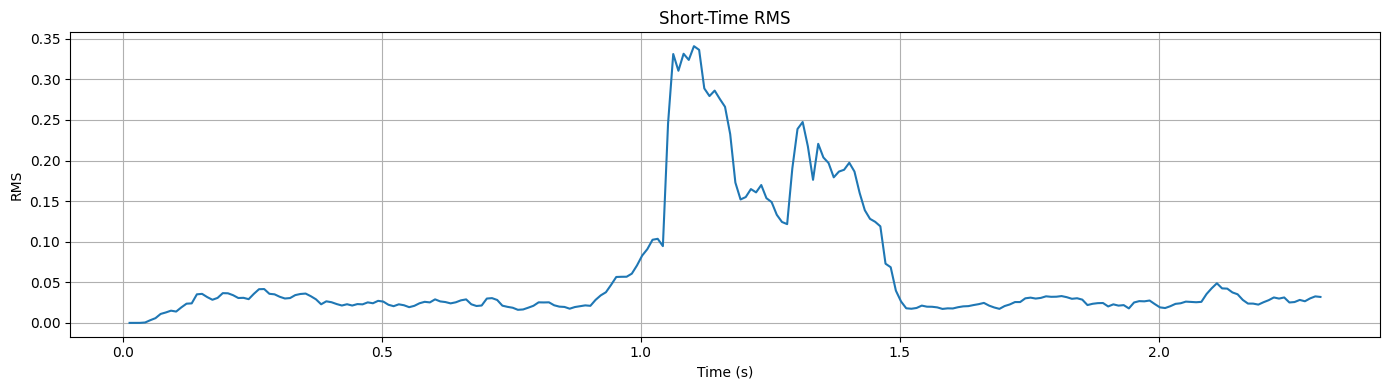

In [26]:
plt.figure(figsize=(14, 4))

plt.plot(times, rms)

plt.title("Short-Time RMS")
plt.xlabel("Time (s)")
plt.ylabel("RMS")
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
sample_files = [
    DATASET_DIR / "khong" / "khong_01.wav",
    DATASET_DIR / "mot" / "mot_01.wav",
    DATASET_DIR / "hai" / "hai_01.wav"
]

# **Hàm vẽ Task B**

In [28]:
def analyze_time_features(file):
    y, sr = librosa.load(
        file,
        sr=16000,
        mono=True
    )

    energy = short_time_energy(
        y,
        FRAME_LENGTH,
        HOP_LENGTH
    )

    rms = short_time_rms(
        y,
        FRAME_LENGTH,
        HOP_LENGTH
    )

    zcr = short_time_zcr(
        y,
        FRAME_LENGTH,
        HOP_LENGTH
    )

    times = frame_times(
        len(energy),
        FRAME_LENGTH,
        HOP_LENGTH,
        SR
    )

    time_wave = np.arange(len(y)) / SR

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 9),
        sharex=True
    )

    axes[0].plot(time_wave, y)
    axes[0].set_title(f"Waveform - {file.name}")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True)

    axes[1].plot(times, energy)
    axes[1].set_title("Short-Time Energy")
    axes[1].set_ylabel("Energy")
    axes[1].grid(True)

    axes[2].plot(times, zcr)
    axes[2].set_title("Zero-Crossing Rate")
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("ZCR")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    return y, energy, rms, zcr, times

# **Chạy cho 3 file**

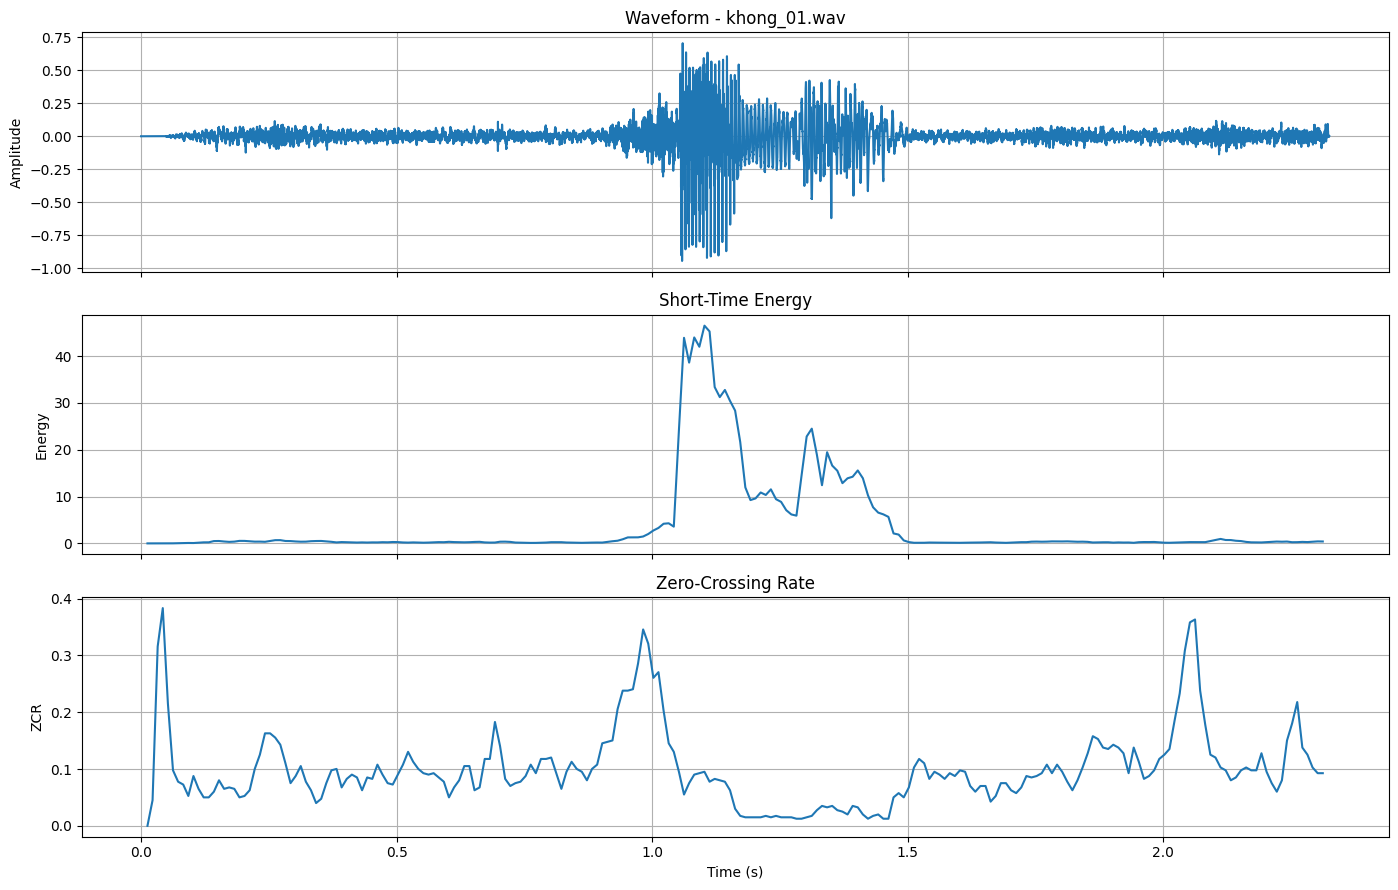

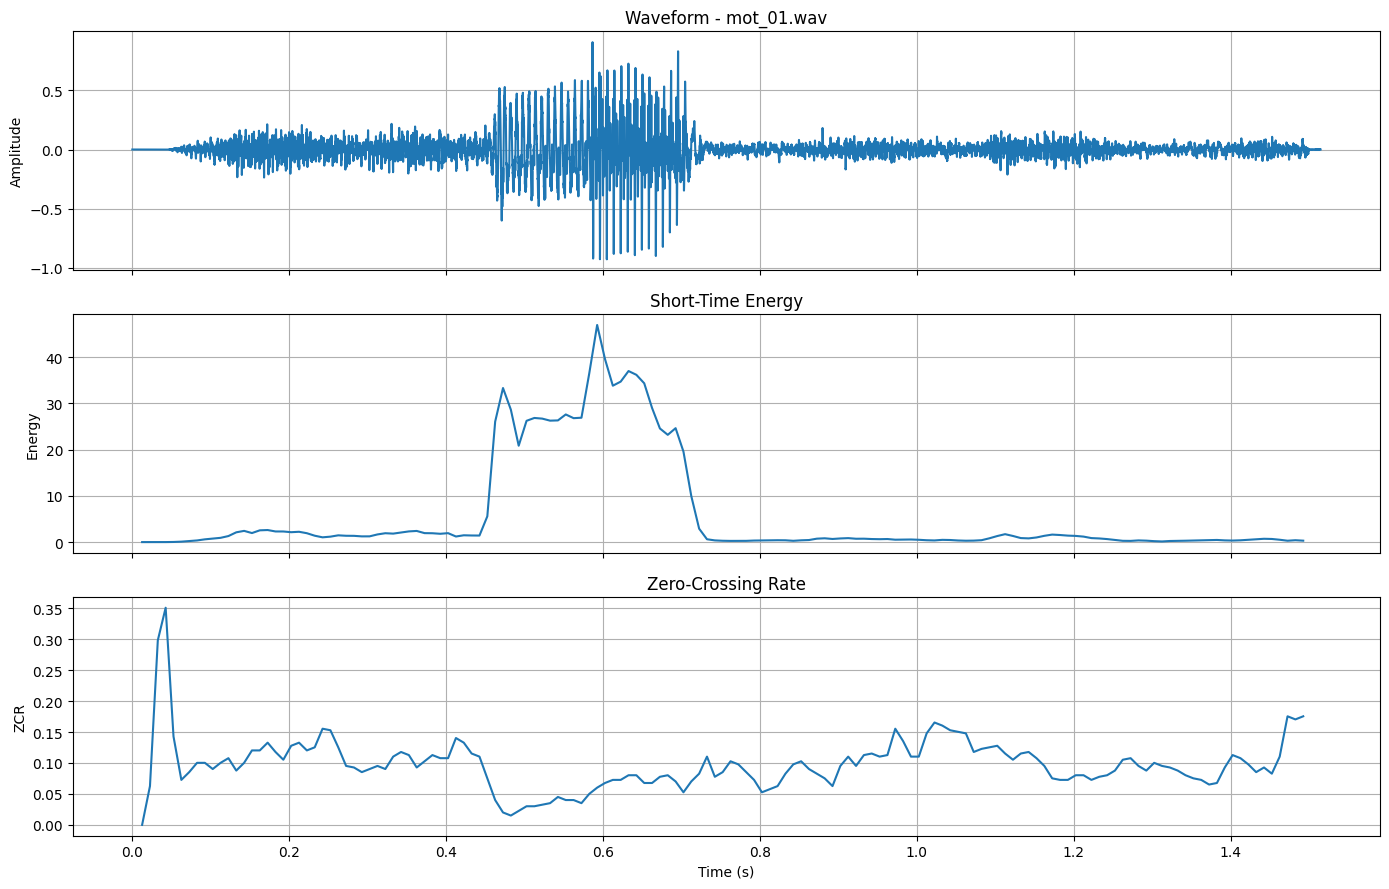

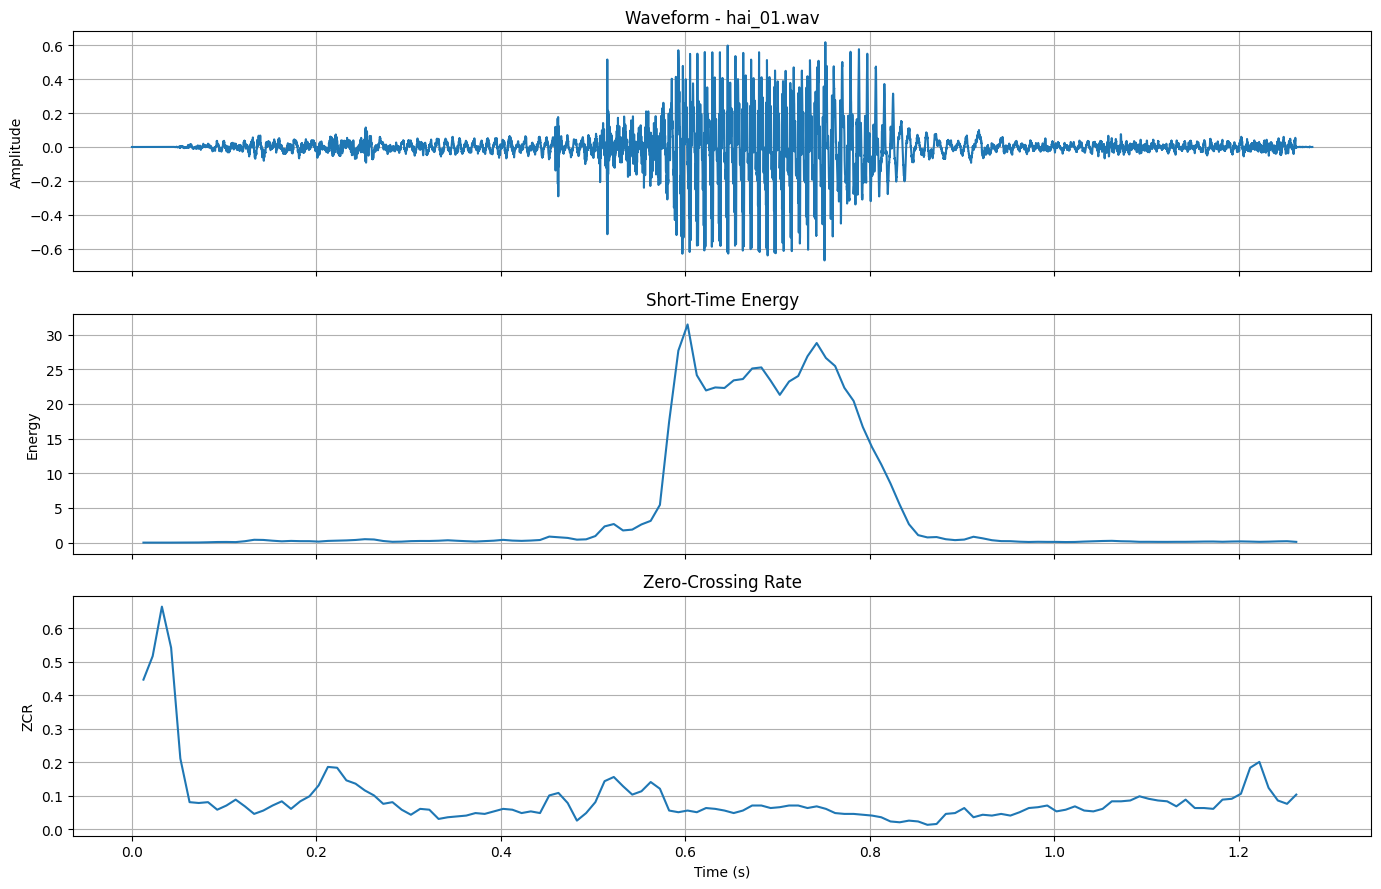

In [29]:
for file in sample_files:
    analyze_time_features(file)

# ***TASK C — ENDPOINT DETECTION***

# **Khai báo thông số**

In [30]:
SR = 16000

FRAME_LENGTH = 400
HOP_LENGTH = 160

MARGIN_MS = 50
MARGIN_FRAMES = int(MARGIN_MS / 10)

print("Frame length:", FRAME_LENGTH)
print("Hop length:", HOP_LENGTH)
print("Margin:", MARGIN_FRAMES, "frames")

Frame length: 400
Hop length: 160
Margin: 5 frames


# **Tính Log-Energy**

In [31]:
def compute_log_energy(y, frame_length=400, hop_length=160):
    frames = librosa.util.frame(
        y,
        frame_length=frame_length,
        hop_length=hop_length
    )

    energy = np.sum(frames ** 2, axis=0)

    eps = 1e-10
    log_energy = 10 * np.log10(energy + eps)

    return energy, log_energy

# **Hàm Endpoint Detection**

In [32]:
def detect_endpoint(
    y,
    sr=16000,
    frame_length=400,
    hop_length=160,
    threshold_db=35,
    margin_ms=50
):
    energy, log_energy = compute_log_energy(
        y,
        frame_length,
        hop_length
    )

    max_energy = np.max(log_energy)

    threshold = max_energy - threshold_db

    speech_frames = np.where(
        log_energy >= threshold
    )[0]

    if len(speech_frames) == 0:
        return 0, len(y), energy, log_energy

    start_frame = speech_frames[0]
    end_frame = speech_frames[-1]

    margin_frames = int(
        margin_ms / (hop_length / sr * 1000)
    )

    start_frame = max(
        0,
        start_frame - margin_frames
    )

    end_frame = min(
        len(log_energy) - 1,
        end_frame + margin_frames
    )

    start_sample = start_frame * hop_length

    end_sample = min(
        len(y),
        end_frame * hop_length + frame_length
    )

    return (
        start_sample,
        end_sample,
        energy,
        log_energy
    )

# **Trim một file**

In [33]:
def trim_speech(
    file,
    threshold_db=35,
    margin_ms=50
):
    y, sr = librosa.load(
        file,
        sr=16000,
        mono=True
    )

    start_sample, end_sample, energy, log_energy = detect_endpoint(
        y,
        sr=sr,
        frame_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH,
        threshold_db=threshold_db,
        margin_ms=margin_ms
    )

    y_trimmed = y[start_sample:end_sample]

    return (
        y,
        y_trimmed,
        sr,
        start_sample,
        end_sample,
        energy,
        log_energy
    )

# **Test với một file**

In [36]:
file = DATASET_DIR / "mot" / "mot_05.wav"

(
    y,
    y_trimmed,
    sr,
    start_sample,
    end_sample,
    energy,
    log_energy
) = trim_speech(file)

print("Original duration:", len(y) / sr, "seconds")
print("Trimmed duration :", len(y_trimmed) / sr, "seconds")
print("Start:", start_sample / sr, "seconds")
print("End:", end_sample / sr, "seconds")

Original duration: 1.8986875 seconds
Trimmed duration : 1.895 seconds
Start: 0.0 seconds
End: 1.895 seconds


# **Vẽ trước và sau khi trim**

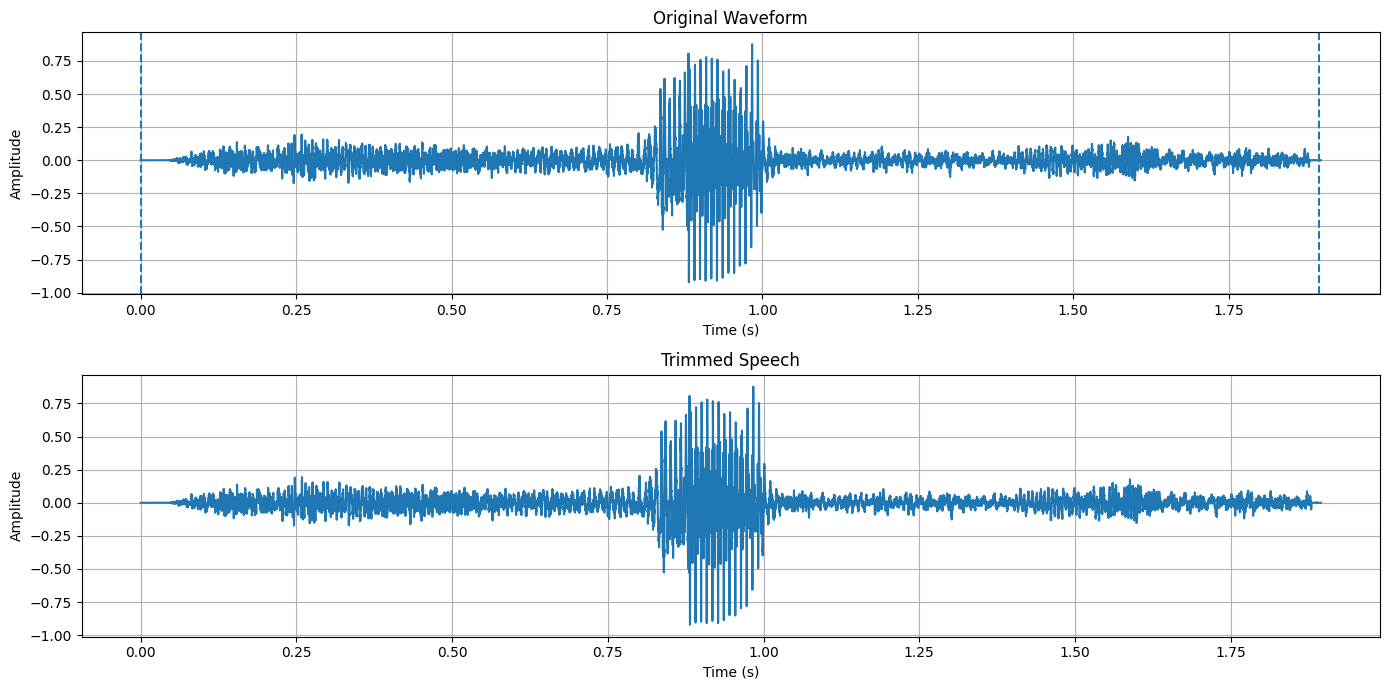

In [37]:
time_original = np.arange(len(y)) / sr
time_trimmed = np.arange(len(y_trimmed)) / sr

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7)
)

axes[0].plot(time_original, y)
axes[0].axvline(
    start_sample / sr,
    linestyle="--"
)
axes[0].axvline(
    end_sample / sr,
    linestyle="--"
)

axes[0].set_title("Original Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)

axes[1].plot(time_trimmed, y_trimmed)

axes[1].set_title("Trimmed Speech")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **Vẽ Log-Energy và threshold**

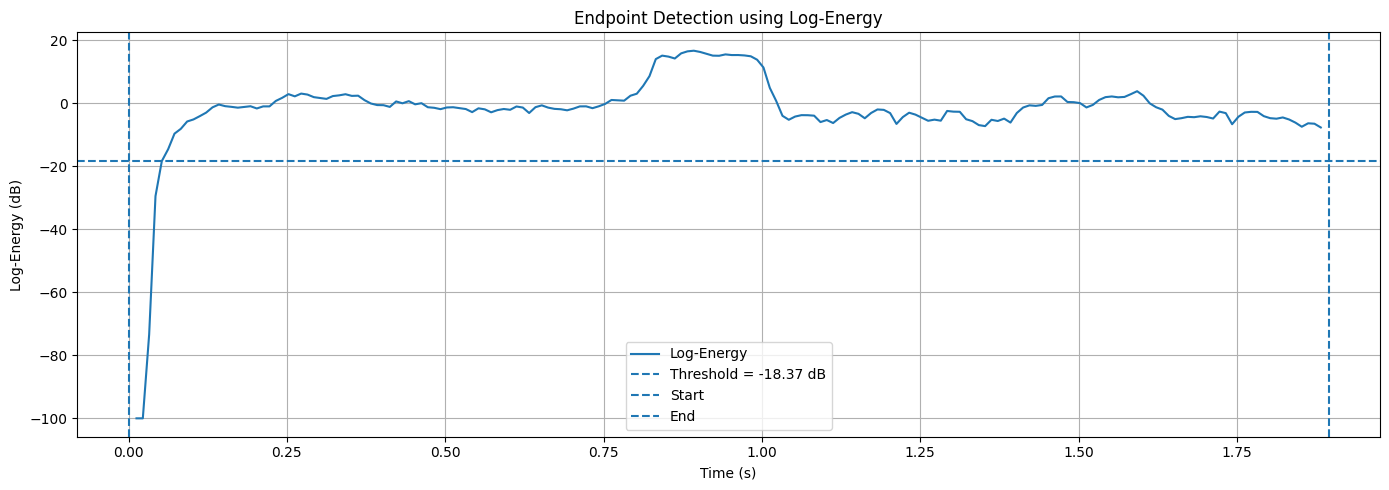

In [38]:
times = frame_times(
    len(log_energy),
    FRAME_LENGTH,
    HOP_LENGTH,
    SR
)

max_energy = np.max(log_energy)
threshold = max_energy - 35

plt.figure(figsize=(14, 5))

plt.plot(
    times,
    log_energy,
    label="Log-Energy"
)

plt.axhline(
    threshold,
    linestyle="--",
    label=f"Threshold = {threshold:.2f} dB"
)

plt.axvline(
    start_sample / sr,
    linestyle="--",
    label="Start"
)

plt.axvline(
    end_sample / sr,
    linestyle="--",
    label="End"
)

plt.xlabel("Time (s)")
plt.ylabel("Log-Energy (dB)")
plt.title("Endpoint Detection using Log-Energy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Kiểm tra ZCR để hỗ trợ endpoint**

In [39]:
zcr = short_time_zcr(
    y,
    FRAME_LENGTH,
    HOP_LENGTH
)

times_zcr = frame_times(
    len(zcr),
    FRAME_LENGTH,
    HOP_LENGTH,
    SR
)

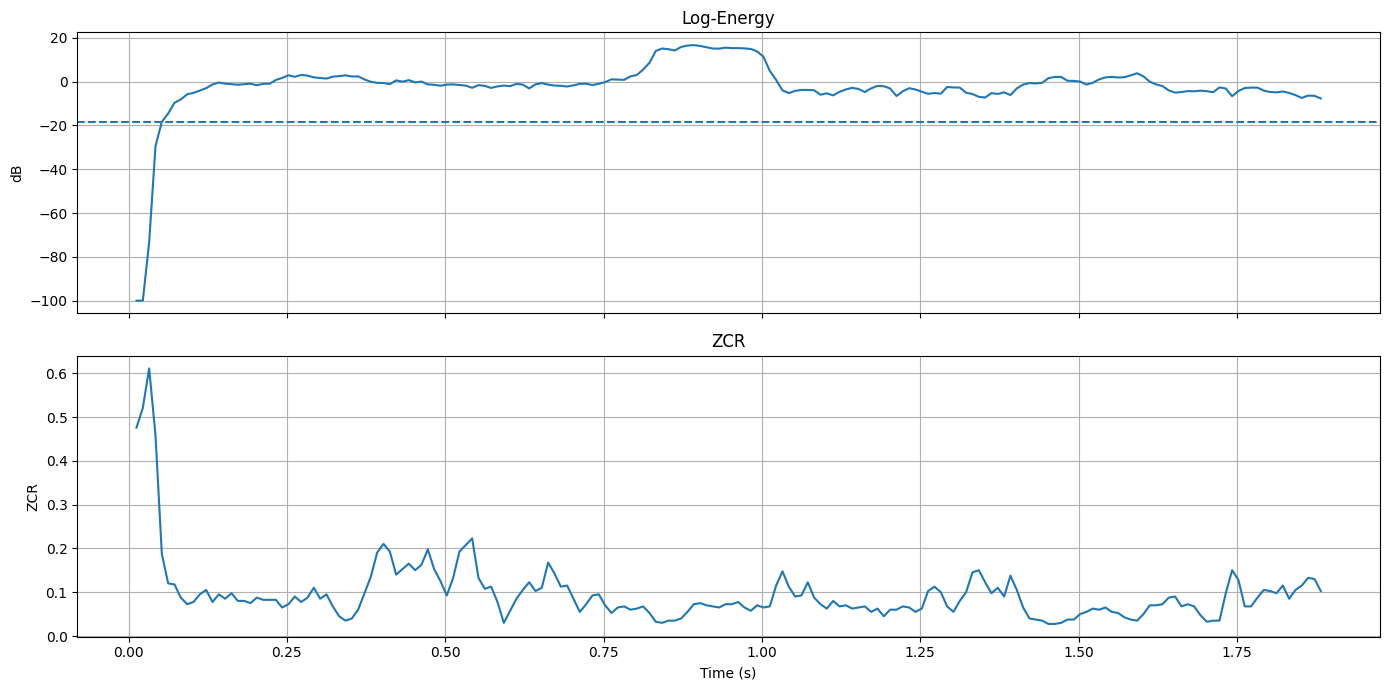

In [40]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

axes[0].plot(times, log_energy)
axes[0].axhline(
    threshold,
    linestyle="--"
)

axes[0].set_title("Log-Energy")
axes[0].set_ylabel("dB")
axes[0].grid(True)

axes[1].plot(times_zcr, zcr)

axes[1].set_title("ZCR")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("ZCR")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **Test trường hợp âm đầu/cuối năng lượng thấp**

In [41]:
test_file = DATASET_DIR / "khong" / "khong_02.wav"
margins = [0, 30, 50]
for margin in margins:

    (
        y_original,
        y_trimmed,
        sr,
        start,
        end,
        energy,
        log_energy
    ) = trim_speech(
        test_file,
        threshold_db=35,
        margin_ms=margin
    )

    print(
        f"Margin = {margin:2d} ms | "
        f"Original = {len(y_original)/sr:.3f}s | "
        f"Trimmed = {len(y_trimmed)/sr:.3f}s"
    )

Margin =  0 ms | Original = 1.984s | Trimmed = 1.915s
Margin = 30 ms | Original = 1.984s | Trimmed = 1.945s
Margin = 50 ms | Original = 1.984s | Trimmed = 1.965s


# **Export file đã trim**

In [43]:
TRIMMED_DIR = Path(
    "/content/drive/MyDrive/Audio/Lab02/dataset_trimmed"
)

TRIMMED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

for label in labels:

    input_dir = DATASET_DIR / label
    output_dir = TRIMMED_DIR / label

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    for file in sorted(input_dir.glob("*.wav")):

        (
            y,
            y_trimmed,
            sr,
            start,
            end,
            energy,
            log_energy
        ) = trim_speech(
            file,
            threshold_db=35,
            margin_ms=50
        )

        output_file = output_dir / file.name

        sf.write(
            output_file,
            y_trimmed,
            sr
        )

print("Đã trim toàn bộ dataset.")

Đã trim toàn bộ dataset.


# **Kiểm tra thời lượng trước và sau**

In [45]:
results = []

for label in labels:

    input_dir = DATASET_DIR / label
    output_dir = TRIMMED_DIR / label

    for file in sorted(input_dir.glob("*.wav")):

        trimmed_file = output_dir / file.name

        y_original, sr = librosa.load(
            file,
            sr=16000,
            mono=True
        )

        y_trimmed, sr = librosa.load(
            trimmed_file,
            sr=16000,
            mono=True
        )

        results.append({
            "Label": label,
            "File": file.name,
            "Original (s)": len(y_original) / sr,
            "Trimmed (s)": len(y_trimmed) / sr
        })

import pandas as pd

duration_df = pd.DataFrame(results)

duration_df

,Label,File,Original (s),Trimmed (s)
0,ba,ba_01.wav,1.194687,1.185
1,ba,ba_02.wav,1.578688,1.575
2,ba,ba_03.wav,1.088000,1.075
3,ba,ba_04.wav,1.514687,1.505
4,ba,ba_05.wav,1.472000,1.465
5,bon,bon_01.wav,1.408000,1.395
6,bon,bon_02.wav,1.493375,1.485
7,bon,bon_03.wav,1.280000,1.275
8,bon,bon_04.wav,1.493375,1.485
9,bon,bon_05.wav,1.301375,1.295


# ***TASK D — MFCC (Mel-Frequency Cepstral Coefficients)***

# **Khai báo tham số MFCC**

In [46]:
MFCC_SR = 16000

MFCC_FRAME_LENGTH = 400      # 25 ms
MFCC_HOP_LENGTH = 160        # 10 ms

PRE_EMPHASIS = 0.97
N_FFT = 512
N_MELS = 24
N_MFCC = 13

print("MFCC parameters:")
print("Sampling rate :", MFCC_SR)
print("Frame length  :", MFCC_FRAME_LENGTH, "samples (25 ms)")
print("Hop length    :", MFCC_HOP_LENGTH, "samples (10 ms)")
print("Pre-emphasis  :", PRE_EMPHASIS)
print("NFFT          :", N_FFT)
print("Mel filters   :", N_MELS)
print("MFCC          :", N_MFCC)

MFCC parameters:
Sampling rate : 16000
Frame length  : 400 samples (25 ms)
Hop length    : 160 samples (10 ms)
Pre-emphasis  : 0.97
NFFT          : 512
Mel filters   : 24
MFCC          : 13


# **Hàm tiền nhấn Pre-emphasis**

In [47]:
def pre_emphasis(signal, alpha=0.97):
    """
    Apply pre-emphasis filter:
        y[n] = x[n] - alpha * x[n-1]
    """

    emphasized = np.empty_like(signal)

    emphasized[0] = signal[0]

    emphasized[1:] = (
        signal[1:]
        - alpha * signal[:-1]
    )

    return emphasized

In [48]:
test_file = DATASET_DIR / "mot" / "mot_05.wav"

y_test, sr_test = librosa.load(
    test_file,
    sr=MFCC_SR,
    mono=True
)

y_pre = pre_emphasis(
    y_test,
    alpha=PRE_EMPHASIS
)

print("Original shape    :", y_test.shape)
print("Pre-emphasis shape:", y_pre.shape)

Original shape    : (30379,)
Pre-emphasis shape: (30379,)


# **Hàm trích xuất MFCC**

In [49]:
def extract_mfcc(
    file,
    sr=16000,
    frame_length=400,
    hop_length=160,
    n_fft=512,
    n_mels=24,
    n_mfcc=13,
    pre_emphasis_alpha=0.97
):
    """
    Extract 13-dimensional MFCC features
    from a speech WAV file.
    """

    # Load audio
    y, sr = librosa.load(
        file,
        sr=sr,
        mono=True
    )

    # Pre-emphasis
    y_pre = pre_emphasis(
        y,
        alpha=pre_emphasis_alpha
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y_pre,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=frame_length,
        window="hamming",
        n_mels=n_mels
    )

    # Convert from (13, T) -> (T, 13)
    mfcc = mfcc.T

    return mfcc

# **Kiểm tra MFCC của một file**

In [50]:
test_file = DATASET_DIR / "mot" / "mot_05.wav"

mfcc_test = extract_mfcc(
    test_file,
    sr=MFCC_SR,
    frame_length=MFCC_FRAME_LENGTH,
    hop_length=MFCC_HOP_LENGTH,
    n_fft=N_FFT,
    n_mels=N_MELS,
    n_mfcc=N_MFCC,
    pre_emphasis_alpha=PRE_EMPHASIS
)

print("File:", test_file.name)
print("MFCC shape:", mfcc_test.shape)
print("Number of frames:", mfcc_test.shape[0])
print("MFCC dimension:", mfcc_test.shape[1])

File: mot_05.wav
MFCC shape: (190, 13)
Number of frames: 190
MFCC dimension: 13


# **Vẽ MFCC heatmap**

In [51]:
def plot_mfcc_heatmap(file):

    mfcc = extract_mfcc(
        file,
        sr=MFCC_SR,
        frame_length=MFCC_FRAME_LENGTH,
        hop_length=MFCC_HOP_LENGTH,
        n_fft=N_FFT,
        n_mels=N_MELS,
        n_mfcc=N_MFCC,
        pre_emphasis_alpha=PRE_EMPHASIS
    )

    plt.figure(figsize=(14, 5))

    librosa.display.specshow(
        mfcc.T,
        x_axis="time",
        sr=MFCC_SR,
        hop_length=MFCC_HOP_LENGTH,
        cmap="viridis"
    )

    plt.colorbar(
        format="%+2.0f"
    )

    plt.xlabel("Time (s)")
    plt.ylabel("MFCC coefficient")

    plt.title(
        f"MFCC - {file.parent.name}/{file.name}"
    )

    plt.tight_layout()
    plt.show()

    return mfcc

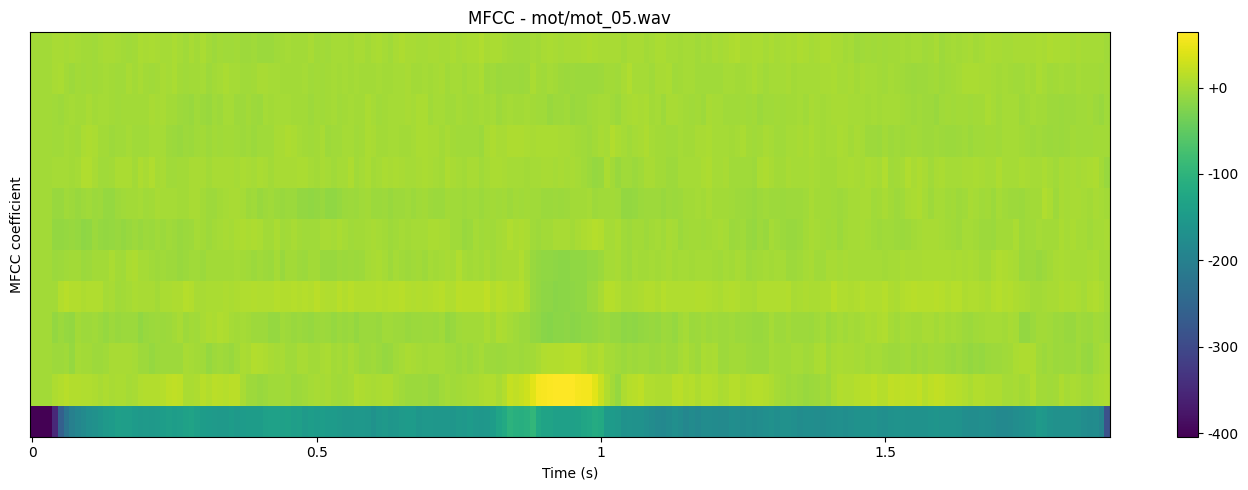

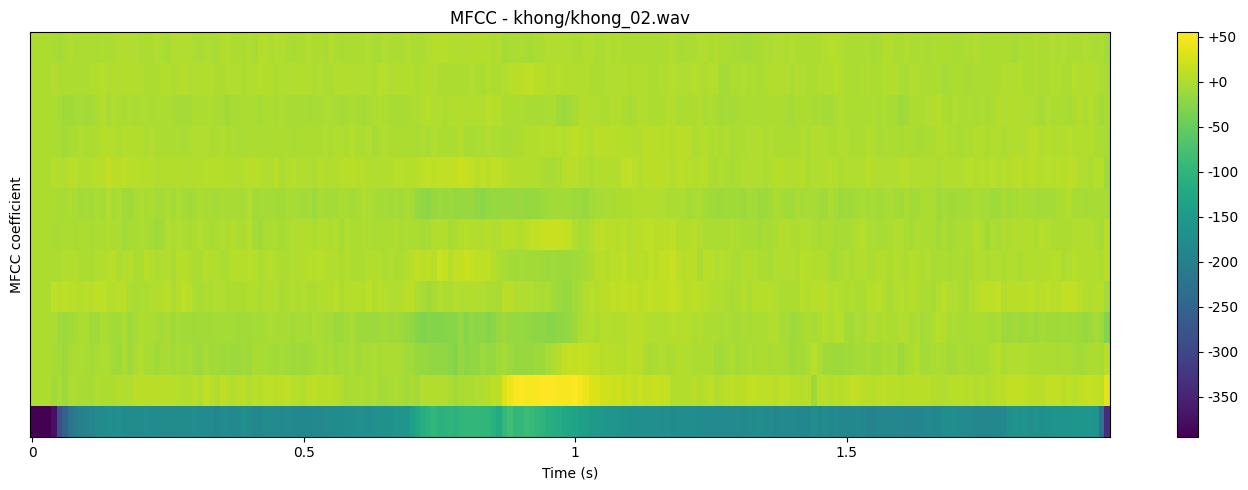

In [52]:
file_mot = DATASET_DIR / "mot" / "mot_05.wav"
file_khong = DATASET_DIR / "khong" / "khong_02.wav"

mfcc_mot = plot_mfcc_heatmap(file_mot)
mfcc_khong = plot_mfcc_heatmap(file_khong)

# **So sánh số frame**

In [53]:
comparison_files = [
    DATASET_DIR / "khong" / "khong_02.wav",
    DATASET_DIR / "mot" / "mot_05.wav",
    DATASET_DIR / "hai" / "hai_01.wav",
    DATASET_DIR / "ba" / "ba_01.wav",
    DATASET_DIR / "bon" / "bon_01.wav"
]

mfcc_info = []

for file in comparison_files:

    mfcc = extract_mfcc(
        file,
        sr=MFCC_SR,
        frame_length=MFCC_FRAME_LENGTH,
        hop_length=MFCC_HOP_LENGTH,
        n_fft=N_FFT,
        n_mels=N_MELS,
        n_mfcc=N_MFCC,
        pre_emphasis_alpha=PRE_EMPHASIS
    )

    mfcc_info.append({
        "Word": file.parent.name,
        "File": file.name,
        "Number of frames": mfcc.shape[0],
        "MFCC dimension": mfcc.shape[1],
        "Shape": mfcc.shape
    })

mfcc_df = pd.DataFrame(mfcc_info)

mfcc_df

,Word,File,Number of frames,MFCC dimension,Shape
0,khong,khong_02.wav,199,13,"(199, 13)"
1,mot,mot_05.wav,190,13,"(190, 13)"
2,hai,hai_01.wav,129,13,"(129, 13)"
3,ba,ba_01.wav,120,13,"(120, 13)"
4,bon,bon_01.wav,141,13,"(141, 13)"


# ***TASK E — Dynamic Time Warping***

# **Chuẩn hóa lại hàm MFCC cho toàn bộ E–G**

In [54]:
from scipy.signal import lfilter

FS = 16000
FRAME_LENGTH = 400      # 25 ms
HOP_LENGTH = 160        # 10 ms

PRE_EMPHASIS_ALPHA = 0.97
N_FFT = 512
N_MELS = 24
N_MFCC = 13


def mfcc_feature(y, use_delta=False):
    """
    Extract MFCC features.

    Output:
        use_delta=False -> shape (T, 13)
        use_delta=True  -> shape (T, 26)
    """

    # Pre-emphasis
    y = lfilter(
        [1.0, -PRE_EMPHASIS_ALPHA],
        [1.0],
        y
    )

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=FS,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,
        n_fft=N_FFT,
        win_length=FRAME_LENGTH,
        hop_length=HOP_LENGTH,
        window="hamming",
        center=False
    )

    # Cepstral Mean Normalization
    mfcc = mfcc - np.mean(
        mfcc,
        axis=1,
        keepdims=True
    )

    if use_delta:

        delta = librosa.feature.delta(mfcc)

        mfcc = np.concatenate(
            [mfcc, delta],
            axis=0
        )

    # librosa: (D, T)
    # DTW:     (T, D)
    return mfcc.T

In [55]:
test_file = TRIMMED_DIR / "mot" / "mot_05.wav"

y_test, _ = librosa.load(
    test_file,
    sr=FS,
    mono=True
)

X_test = mfcc_feature(y_test)

print("MFCC shape:", X_test.shape)

MFCC shape: (187, 13)


# **Local Distance Matrix**

In [56]:
def local_distance_matrix(X, Y):
    """
    Compute Euclidean local-distance matrix.

    X: (N, D)
    Y: (M, D)

    Return:
        C: (N, M)
    """

    N = X.shape[0]
    M = Y.shape[0]

    C = np.zeros((N, M))

    for i in range(N):
        for j in range(M):

            C[i, j] = np.linalg.norm(
                X[i] - Y[j]
            )

    return C

# **Tự cài đặt DTW**

In [57]:
def dtw_distance(X, Y):
    """
    Dynamic Time Warping.

    X: (N, D)
    Y: (M, D)

    Returns:
        dtw_norm
        optimal_path
        local_distance_matrix
        accumulated_cost_matrix
    """

    N = X.shape[0]
    M = Y.shape[0]

    # Local distance
    C = local_distance_matrix(X, Y)

    # Accumulated cost matrix
    D = np.full(
        (N + 1, M + 1),
        np.inf
    )

    D[0, 0] = 0.0

    # Backtracking matrix
    back = np.zeros(
        (N + 1, M + 1, 2),
        dtype=int
    )

    # Dynamic programming
    for i in range(1, N + 1):

        for j in range(1, M + 1):

            choices = [
                (D[i - 1, j], i - 1, j),       # vertical
                (D[i, j - 1], i, j - 1),       # horizontal
                (D[i - 1, j - 1], i - 1, j - 1) # diagonal
            ]

            best_cost, pi, pj = min(
                choices,
                key=lambda x: x[0]
            )

            D[i, j] = C[i - 1, j - 1] + best_cost

            back[i, j] = [pi, pj]

    # ------------------------------------------
    # Backtracking
    # ------------------------------------------

    path = []

    i = N
    j = M

    while i > 0 or j > 0:

        path.append(
            (i - 1, j - 1)
        )

        i, j = back[i, j]

    path.reverse()

    # ------------------------------------------
    # Normalized DTW
    # ------------------------------------------

    path_length = len(path)

    dtw_norm = (
        D[N, M] /
        max(path_length, 1)
    )

    return (
        dtw_norm,
        path,
        C,
        D[1:, 1:]
    )

# **Kiểm tra DTW với cùng một file**

In [58]:
X = mfcc_feature(y_test)

dtw_same, path_same, C_same, D_same = dtw_distance(
    X,
    X
)

print("DTW_norm của file với chính nó:", dtw_same)
print("Path length:", len(path_same))

DTW_norm của file với chính nó: 0.0
Path length: 188


# **DTW giữa hai lần nói cùng một từ**

In [59]:
file_same_1 = TRIMMED_DIR / "mot" / "mot_04.wav"
file_same_2 = TRIMMED_DIR / "mot" / "mot_05.wav"

y1, _ = librosa.load(
    file_same_1,
    sr=FS,
    mono=True
)

y2, _ = librosa.load(
    file_same_2,
    sr=FS,
    mono=True
)

X1 = mfcc_feature(y1)
X2 = mfcc_feature(y2)

dtw_same, path_same, C_same, D_same = dtw_distance(
    X1,
    X2
)

print("=== SAME WORD ===")
print("Word: mot vs mot")
print("X shape:", X1.shape)
print("Y shape:", X2.shape)
print("DTW_norm:", dtw_same)
print("Path length:", len(path_same))

=== SAME WORD ===
Word: mot vs mot
X shape: (180, 13)
Y shape: (187, 13)
DTW_norm: 19.973362282938055
Path length: 203


# **DTW giữa hai từ khác nhau**

In [60]:
file_diff_1 = TRIMMED_DIR / "mot" / "mot_05.wav"
file_diff_2 = TRIMMED_DIR / "hai" / "hai_05.wav"

y3, _ = librosa.load(
    file_diff_1,
    sr=FS,
    mono=True
)

y4, _ = librosa.load(
    file_diff_2,
    sr=FS,
    mono=True
)

X3 = mfcc_feature(y3)
X4 = mfcc_feature(y4)

dtw_diff, path_diff, C_diff, D_diff = dtw_distance(
    X3,
    X4
)

print("=== DIFFERENT WORD ===")
print("Word: mot vs hai")
print("X shape:", X3.shape)
print("Y shape:", X4.shape)
print("DTW_norm:", dtw_diff)
print("Path length:", len(path_diff))

=== DIFFERENT WORD ===
Word: mot vs hai
X shape: (187, 13)
Y shape: (153, 13)
DTW_norm: 26.323778720231644
Path length: 208


# **Vẽ Local-Distance Matrix + Optimal Path**

In [61]:
def plot_dtw_result(
    C,
    path,
    title
):

    path_i = [p[0] for p in path]
    path_j = [p[1] for p in path]

    plt.figure(figsize=(10, 6))

    plt.imshow(
        C.T,
        origin="lower",
        aspect="auto",
        cmap="viridis"
    )

    plt.plot(
        path_i,
        path_j,
        linewidth=2
    )

    plt.colorbar(
        label="Euclidean distance"
    )

    plt.xlabel("Frame sequence X")
    plt.ylabel("Frame sequence Y")

    plt.title(title)

    plt.tight_layout()
    plt.show()

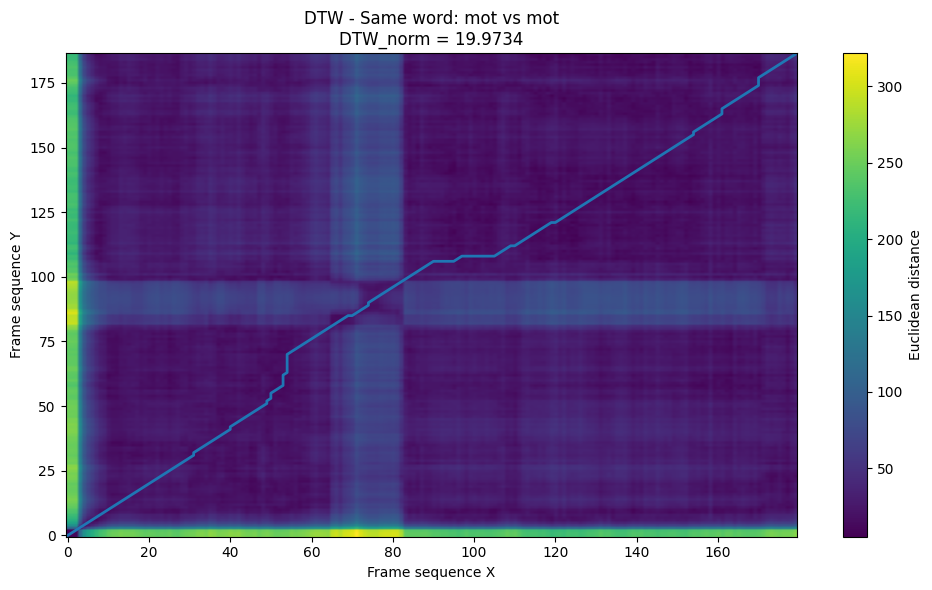

In [62]:
plot_dtw_result(
    C_same,
    path_same,
    f"DTW - Same word: mot vs mot\n"
    f"DTW_norm = {dtw_same:.4f}"
)

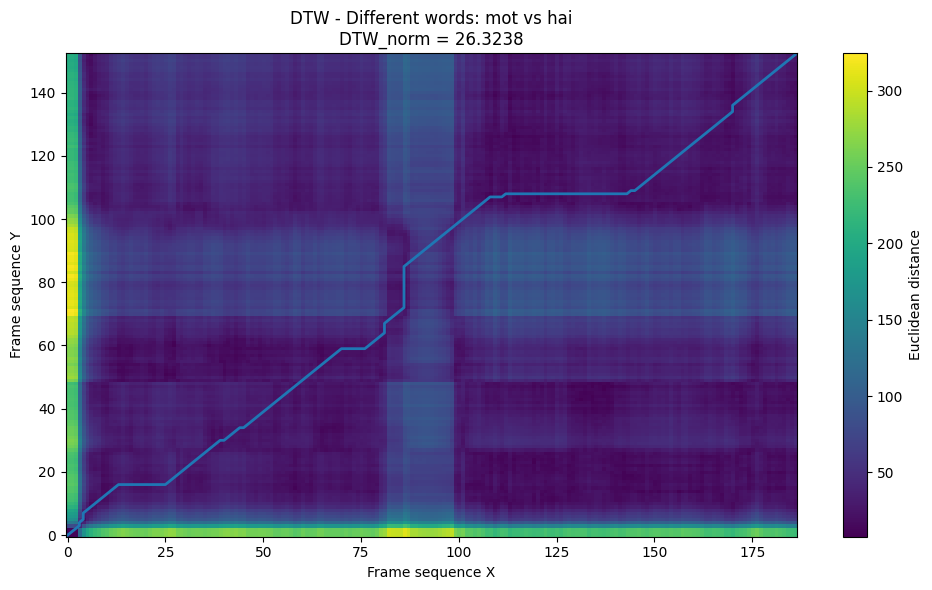

In [63]:
plot_dtw_result(
    C_diff,
    path_diff,
    f"DTW - Different words: mot vs hai\n"
    f"DTW_norm = {dtw_diff:.4f}"
)

# ***TASK F — Nearest-Template Recognizer***

# **Khai báo Labels**

In [64]:
LABELS = [
    "khong",
    "mot",
    "hai",
    "ba",
    "bon"
]

# **Tạo templates**

In [65]:
def build_templates(
    root,
    use_delta=False
):

    templates = {
        label: []
        for label in LABELS
    }

    for label in LABELS:

        files = sorted(
            (Path(root) / label).glob("*.wav")
        )

        # First 3 files = training templates
        train_files = files[:3]

        for file in train_files:

            y, _ = librosa.load(
                file,
                sr=FS,
                mono=True
            )

            feature = mfcc_feature(
                y,
                use_delta=use_delta
            )

            templates[label].append(
                feature
            )

    return templates

# **Recognizer**

In [66]:
def recognize(
    file,
    templates,
    use_delta=False
):

    y, _ = librosa.load(
        file,
        sr=FS,
        mono=True
    )

    X = mfcc_feature(
        y,
        use_delta=use_delta
    )

    scores = {}

    for label, references in templates.items():

        template_distances = []

        for reference in references:

            dtw_norm, _, _, _ = dtw_distance(
                X,
                reference
            )

            template_distances.append(
                dtw_norm
            )

        # Best template for this label
        scores[label] = min(
            template_distances
        )

    # Sort from nearest to farthest
    sorted_scores = sorted(
        scores.items(),
        key=lambda x: x[1]
    )

    prediction = sorted_scores[0][0]

    return prediction, sorted_scores

# **Test 5 files và Top-3**

In [67]:
templates_trimmed = build_templates(
    TRIMMED_DIR,
    use_delta=False
)

top3_results = []

for label in LABELS:

    test_files = sorted(
        (TRIMMED_DIR / label).glob("*.wav")
    )[3:]

    for file in test_files:

        prediction, scores = recognize(
            file,
            templates_trimmed,
            use_delta=False
        )

        top3 = scores[:3]

        print(
            f"\nFile: {file.name}"
        )

        print(
            f"True label: {label}"
        )

        print(
            f"Prediction: {prediction}"
        )

        print("Top-3:")

        for rank, (lab, score) in enumerate(
            top3,
            start=1
        ):

            print(
                f"  {rank}. "
                f"{lab:<6s} "
                f"DTW = {score:.4f}"
            )

        top3_results.append({
            "File": file.name,
            "True": label,
            "Prediction": prediction,
            "Top1": top3[0][0],
            "Top1_DTWN": top3[0][1],
            "Top2": top3[1][0],
            "Top2_DTWN": top3[1][1],
            "Top3": top3[2][0],
            "Top3_DTWN": top3[2][1]
        })


File: khong_04.wav
True label: khong
Prediction: khong
Top-3:
  1. khong  DTW = 16.9156
  2. hai    DTW = 21.5795
  3. ba     DTW = 22.7349

File: khong_05.wav
True label: khong
Prediction: khong
Top-3:
  1. khong  DTW = 17.1427
  2. hai    DTW = 22.7382
  3. ba     DTW = 24.3132

File: mot_04.wav
True label: mot
Prediction: mot
Top-3:
  1. mot    DTW = 20.3962
  2. khong  DTW = 20.9099
  3. hai    DTW = 23.5433

File: mot_05.wav
True label: mot
Prediction: mot
Top-3:
  1. mot    DTW = 19.5593
  2. bon    DTW = 22.1344
  3. khong  DTW = 22.1949

File: hai_04.wav
True label: hai
Prediction: hai
Top-3:
  1. hai    DTW = 17.2459
  2. khong  DTW = 21.7804
  3. ba     DTW = 22.0913

File: hai_05.wav
True label: hai
Prediction: hai
Top-3:
  1. hai    DTW = 20.9191
  2. ba     DTW = 23.7394
  3. khong  DTW = 25.0588

File: ba_04.wav
True label: ba
Prediction: ba
Top-3:
  1. ba     DTW = 20.6605
  2. khong  DTW = 21.7465
  3. hai    DTW = 23.3557

File: ba_05.wav
True label: ba
Prediction: ba

# ***TASK G — Accuracy + Confusion Matrix***

# **Hàm đánh giá**

In [68]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

def evaluate_recognizer(
    root,
    use_delta=False
):

    templates = build_templates(
        root,
        use_delta=use_delta
    )

    y_true = []
    y_pred = []

    result_rows = []

    for label in LABELS:

        files = sorted(
            (Path(root) / label).glob("*.wav")
        )

        # Last 2 files = test
        test_files = files[3:]

        for file in test_files:

            prediction, scores = recognize(
                file,
                templates,
                use_delta=use_delta
            )

            y_true.append(label)
            y_pred.append(prediction)

            result_rows.append({
                "File": file.name,
                "True": label,
                "Prediction": prediction,
                "Top1": scores[0][0],
                "Top1_DTWN": scores[0][1],
                "Top2": scores[1][0],
                "Top2_DTWN": scores[1][1]
            })

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=LABELS
    )

    results_df = pd.DataFrame(
        result_rows
    )

    return (
        accuracy,
        cm,
        results_df,
        y_true,
        y_pred
    )

# **Baseline có Endpoint + MFCC 13**

In [69]:
accuracy_trim, cm_trim, results_trim, y_true_trim, y_pred_trim = evaluate_recognizer(
    TRIMMED_DIR,
    use_delta=False
)

print(
    f"Baseline Accuracy = "
    f"{accuracy_trim * 100:.2f}%"
)

print("\nConfusion Matrix:")
print(cm_trim)

Baseline Accuracy = 100.00%

Confusion Matrix:
[[2 0 0 0 0]
 [0 2 0 0 0]
 [0 0 2 0 0]
 [0 0 0 2 0]
 [0 0 0 0 2]]


# **Vẽ Confusion Matrix**

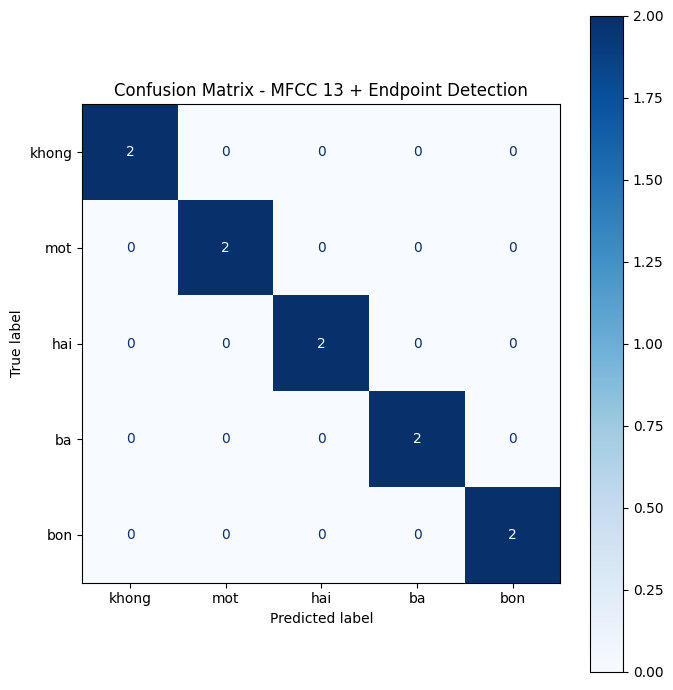

In [70]:
fig, ax = plt.subplots(
    figsize=(7, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_trim,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title(
    "Confusion Matrix - MFCC 13 + Endpoint Detection"
)

plt.tight_layout()
plt.show()

# **THÍ NGHIỆM E1 — Không Trim vs. Có Trim**

In [71]:
accuracy_no_trim, cm_no_trim, results_no_trim, y_true_no_trim, y_pred_no_trim = evaluate_recognizer(
    DATASET_DIR,
    use_delta=False
)

print(
    f"Accuracy WITHOUT endpoint detection = "
    f"{accuracy_no_trim * 100:.2f}%"
)

Accuracy WITHOUT endpoint detection = 100.00%


In [72]:
#So sánh
e1_df = pd.DataFrame({
    "Condition": [
        "Without Endpoint Detection",
        "With Endpoint Detection"
    ],
    "Accuracy (%)": [
        accuracy_no_trim * 100,
        accuracy_trim * 100
    ]
})

e1_df

,Condition,Accuracy (%)
0,Without Endpoint Detection,100.0
1,With Endpoint Detection,100.0


# **THÍ NGHIỆM E2 — MFCC 13 vs MFCC + Delta**

In [75]:
# MFCC 13
accuracy_mfcc13 = accuracy_trim

In [76]:
# MFCC + Delta
accuracy_delta, cm_delta, results_delta, y_true_delta, y_pred_delta = evaluate_recognizer(
    TRIMMED_DIR,
    use_delta=True
)

print(
    f"MFCC + Delta Accuracy = "
    f"{accuracy_delta * 100:.2f}%"
)

MFCC + Delta Accuracy = 100.00%


In [77]:
# Bảng so sánh
e2_df = pd.DataFrame({
    "Feature": [
        "MFCC 13",
        "MFCC 13 + Delta"
    ],
    "Dimension/frame": [
        13,
        26
    ],
    "Accuracy (%)": [
        accuracy_trim * 100,
        accuracy_delta * 100
    ]
})

e2_df

,Feature,Dimension/frame,Accuracy (%)
0,MFCC 13,13,100.0
1,MFCC 13 + Delta,26,100.0


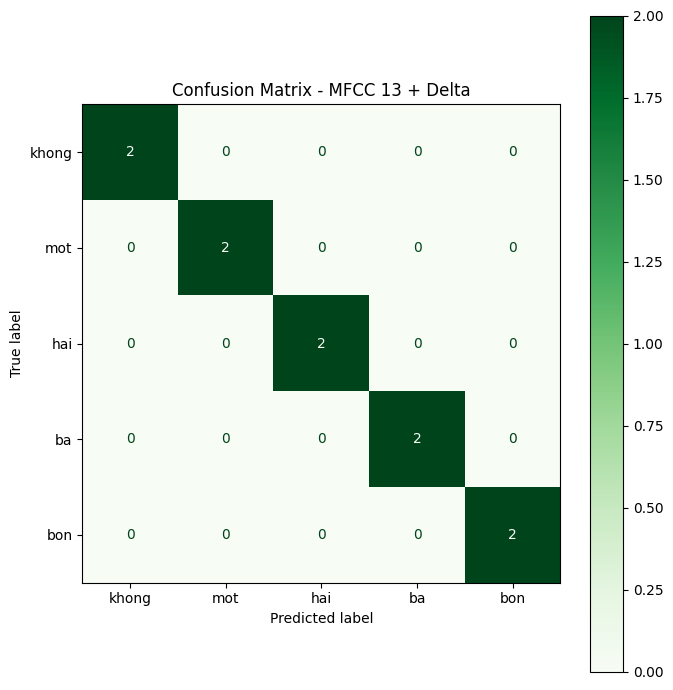

In [78]:
# Confusion Matrix của MFCC + Delta
fig, ax = plt.subplots(
    figsize=(7, 7)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_delta,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    cmap="Greens",
    values_format="d"
)

plt.title(
    "Confusion Matrix - MFCC 13 + Delta"
)

plt.tight_layout()
plt.show()

In [79]:
# Tổng hợp E1 + E2

summary_df = pd.DataFrame({
    "Experiment": [
        "E1 - Without Endpoint",
        "E1 - With Endpoint",
        "E2 - MFCC 13",
        "E2 - MFCC + Delta"
    ],

    "Feature": [
        "MFCC 13",
        "MFCC 13",
        "MFCC 13",
        "MFCC 13 + Delta"
    ],

    "Endpoint": [
        "No",
        "Yes",
        "Yes",
        "Yes"
    ],

    "Accuracy (%)": [
        accuracy_no_trim * 100,
        accuracy_trim * 100,
        accuracy_trim * 100,
        accuracy_delta * 100
    ]
})

summary_df

,Experiment,Feature,Endpoint,Accuracy (%)
0,E1 - Without Endpoint,MFCC 13,No,100.0
1,E1 - With Endpoint,MFCC 13,Yes,100.0
2,E2 - MFCC 13,MFCC 13,Yes,100.0
3,E2 - MFCC + Delta,MFCC 13 + Delta,Yes,100.0
